In [1]:
!where python

C:\Users\akash\anaconda3\envs\audiodeepfake\python.exe
C:\Users\akash\AppData\Local\Microsoft\WindowsApps\python.exe


In [2]:
import sys
import tensorflow as tf
import librosa
import numpy as np
import random

print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Librosa version:", librosa.__version__)


Python version: 3.10.18 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:08:55) [MSC v.1929 64 bit (AMD64)]
TensorFlow version: 2.15.0
Librosa version: 0.10.1


In [3]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
import librosa, librosa.display, os

#unseen imports
import soundfile as sf
from pydub import AudioSegment
!pip install imageio[ffmpeg]
!pip install pydub ffmpeg-python

C:\Users\akash\anaconda3\envs\audiodeepfake\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [4]:
base_path = r"D:/ASVspoofDataset/LA/LA"

train_wav = os.path.join(base_path, "ASVspoof2019_LA_train/flac")
dev_wav   = os.path.join(base_path, "ASVspoof2019_LA_dev/flac")
eval_wav  = os.path.join(base_path, "ASVspoof2019_LA_eval/flac")

train_protocol = os.path.join(base_path, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
dev_protocol   = os.path.join(base_path, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")
eval_protocol  = os.path.join(base_path, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")

In [5]:
#def load_protocol(protocol_file, wav_dir):
#    files, labels = [], []
#    with open(protocol_file, 'r') as f:
#        for line in f:
#            parts = line.strip().split()
#            file_name, label = parts[0], parts[1]
#            file_path = os.path.join(wav_dir, file_name + ".flac")
#            files.append(file_path)
#            labels.append(1 if label == "bonafide" else 0)
#    return files, labels

def load_protocol(protocol_file, wav_dir):
    files, labels = [], []
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            
            # For ASVspoof2019: first col = file ID, last col = label
            file_id = parts[1]          # e.g., "LA_T_1000137"
            label = parts[-1]           # e.g., "bonafide" or "spoof"
            
            file_path = os.path.join(wav_dir, file_id + ".flac")
            files.append(file_path)
            
            labels.append(1 if label.lower() == "bonafide" else 0)
    return files, labels


def extract_melspectrogram(file_path, n_mels=128, max_len=128):
    y, sr = librosa.load(file_path, sr=16000)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]
    return mel_db


#generator class
class AudioGenerator(Sequence):
    def __init__(self, files, labels, batch_size=32, n_mels=128, max_len=128, shuffle=True):
        self.files = files
        self.labels = labels
        self.batch_size = batch_size
        self.n_mels = n_mels
        self.max_len = max_len
        self.shuffle = shuffle
        self.indices = np.arange(len(self.files))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.files) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_files = [self.files[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        X, y = [], []
        for f, l in zip(batch_files, batch_labels):
            mel = extract_melspectrogram(f, n_mels=self.n_mels, max_len=self.max_len)
            X.append(mel)
            y.append(l)

        X = np.array(X)[..., np.newaxis]   # add channel dim
        y = np.array(y)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

#prepare dataset
def prepare_dataset(files, labels):
    X = np.array([extract_melspectrogram(f) for f in files])
    X = X[..., np.newaxis]
    y = np.array(labels)
    return X, y

In [6]:
def stratified_sample(files, labels, n_per_class):
    """Return n_per_class samples for each class (0=spoof, 1=bonafide)."""
    files = np.array(files)
    labels = np.array(labels)

    result_files, result_labels = [], []

    for cls in [0, 1]:
        idx = np.where(labels == cls)[0]
        chosen = np.random.choice(idx, size=n_per_class, replace=False)
        result_files.extend(files[chosen])
        result_labels.extend(labels[chosen])

    # Shuffle together
    combined = list(zip(result_files, result_labels))
    random.shuffle(combined)
    result_files, result_labels = zip(*combined)

    return list(result_files), list(result_labels)

In [7]:
#train_files, train_labels = load_protocol(train_protocol, train_wav)
#dev_files, dev_labels     = load_protocol(dev_protocol, dev_wav)
#eval_files, eval_labels   = load_protocol(eval_protocol, eval_wav)

# Small subset for quick testing
#X_train, y_train = prepare_dataset(train_files[:200], train_labels[:200])
#X_dev, y_dev     = prepare_dataset(dev_files[:100], dev_labels[:100])
#X_eval, y_eval   = prepare_dataset(eval_files[:100], eval_labels[:100])

#print("Shapes:", X_train.shape, X_dev.shape, X_eval.shape)


train_files, train_labels = load_protocol(train_protocol, train_wav)
dev_files, dev_labels     = load_protocol(dev_protocol, dev_wav)
eval_files, eval_labels   = load_protocol(eval_protocol, eval_wav)

# Apply stratified sampling
train_files, train_labels = stratified_sample(train_files, train_labels, n_per_class=2000)  # 2000 spoof + 2000 bonafide
dev_files, dev_labels     = stratified_sample(dev_files, dev_labels, n_per_class=1000)      # 1000 spoof + 1000 bonafide

# Convert into spectrogram features
#X_train, y_train = prepare_dataset(train_files, train_labels)
#X_dev, y_dev     = prepare_dataset(dev_files, dev_labels)
# X_eval, y_eval   = prepare_dataset(eval_files[:200], eval_labels[:200])  # smaller subset for testing
#X_eval, y_eval = prepare_dataset(eval_files, eval_labels)

train_gen = AudioGenerator(train_files, train_labels, batch_size=32)
dev_gen   = AudioGenerator(dev_files, dev_labels, batch_size=32)
eval_gen  = AudioGenerator(eval_files, eval_labels, batch_size=32, shuffle=False)

#class weights :
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert labels to numpy array
train_labels_array = np.array(train_labels)

# Compute class weights automatically (for classes 0=spoof, 1=bonafide)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_array),
    y=train_labels_array
)
class_weights = dict(enumerate(class_weights))

print("Computed class weights:", class_weights)

Computed class weights: {0: 1.0, 1: 1.0}


In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 57600)             0         
                                                                 
 dense (Dense)               (None, 64)               

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=dev_gen,
    epochs=20,              # you can increase later
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/20


125/125 [==============================] - 63s 499ms/step - loss: 2.6020 - accuracy: 0.6982 - val_loss: 0.4312 - val_accuracy: 0.7980
Epoch 2/20
125/125 [==============================] - 51s 409ms/step - loss: 0.3687 - accuracy: 0.8332 - val_loss: 0.2538 - val_accuracy: 0.8910
Epoch 3/20
125/125 [==============================] - 50s 403ms/step - loss: 0.2991 - accuracy: 0.8665 - val_loss: 0.2725 - val_accuracy: 0.8780
Epoch 4/20
125/125 [==============================] - 50s 401ms/step - loss: 0.2038 - accuracy: 0.9168 - val_loss: 0.1607 - val_accuracy: 0.9370
Epoch 5/20
125/125 [==============================] - 51s 406ms/step - loss: 0.1655 - accuracy: 0.9270 - val_loss: 0.1258 - val_accuracy: 0.9520
Epoch 6/20
125/125 [==============================] - 53s 424ms/step - loss: 0.1406 - accuracy: 0.9490 - val_loss: 0.1310 - val_accuracy: 0.9465
Epoch 7/20
125/125 [==============================] - 61s 486ms/step - loss: 0.1171 - accuracy: 0.9553 - val_loss: 0.1702 - val_

In [10]:
# Predict on dev set
# --- Evaluate on DEV set ---
y_pred_dev = (model.predict(dev_gen) > 0.5).astype("int32")
print("🔹 Validation (Dev set) Performance")
print(classification_report(dev_labels, y_pred_dev, target_names=["spoof", "bonafide"]))

# --- Evaluate on EVAL set ---
y_pred_eval = (model.predict(eval_gen) > 0.5).astype("int32")
print("\n🔹 Evaluation (Eval set) Performance")
print(classification_report(eval_labels, y_pred_eval, target_names=["spoof", "bonafide"]))

63/63 [==============================] - 13s 204ms/step
🔹 Validation (Dev set) Performance
              precision    recall  f1-score   support

       spoof       0.50      0.50      0.50      1000
    bonafide       0.49      0.49      0.49      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000

2227/2227 [==============================] - 579s 260ms/step

🔹 Evaluation (Eval set) Performance
              precision    recall  f1-score   support

       spoof       0.99      0.86      0.92     63882
    bonafide       0.43      0.94      0.59      7355

    accuracy                           0.87     71237
   macro avg       0.71      0.90      0.76     71237
weighted avg       0.93      0.87      0.89     71237



In [11]:
print(len(train_gen))
print(len(dev_gen))
print(set(train_files[:5]) & set(dev_files[:5]))

125
63
set()


In [12]:
def visualize_results(history, model, dev_gen, dev_labels, eval_gen, eval_labels, train_files):
    # ------------------ 1. Training curves ------------------
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.show()

    # ------------------ 2. Confusion Matrices ------------------
    print("\n🔹 Confusion Matrix (Dev set)")
    y_pred_dev = (model.predict(dev_gen) > 0.5).astype("int32")
    cm_dev = confusion_matrix(dev_labels, y_pred_dev)
    ConfusionMatrixDisplay(confusion_matrix=cm_dev, display_labels=["Spoof","Bonafide"]).plot(cmap="Blues", values_format="d")
    plt.show()

    print("\n🔹 Confusion Matrix (Eval set)")
    y_pred_eval = (model.predict(eval_gen) > 0.5).astype("int32")
    cm_eval = confusion_matrix(eval_labels, y_pred_eval)
    ConfusionMatrixDisplay(confusion_matrix=cm_eval, display_labels=["Spoof","Bonafide"]).plot(cmap="Blues", values_format="d")
    plt.show()

    # ------------------ 3. ROC & PR curves ------------------
    y_scores_dev = model.predict(dev_gen).ravel()
    fpr, tpr, _ = roc_curve(dev_labels, y_scores_dev)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(dev_labels, y_scores_dev)

    plt.figure(figsize=(12,5))

    # ROC
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title("ROC Curve (Dev Set)")
    plt.legend()

    # Precision-Recall
    plt.subplot(1,2,2)
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (Dev Set)")
    plt.show()

    # ------------------ 4. Mel-Spectrogram Examples ------------------
    def plot_melspectrogram(file_path):
        y, sr = librosa.load(file_path, sr=16000)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        plt.figure(figsize=(10,4))
        librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Mel-Spectrogram: {os.path.basename(file_path)}")
        plt.show()

    print("\n🔹 Example Mel-Spectrograms")
    plot_melspectrogram(train_files[0])   # Likely bonafide
    plot_melspectrogram(train_files[-1])  # Likely spoof

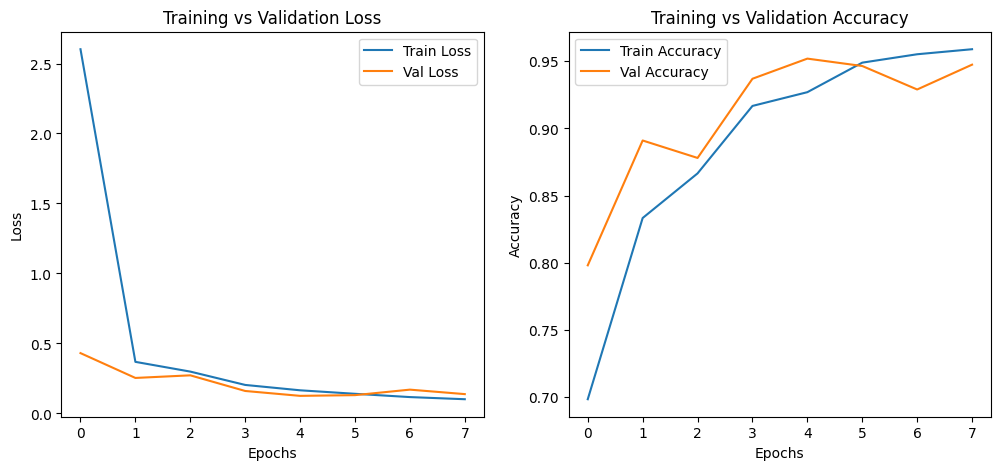


🔹 Confusion Matrix (Dev set)
63/63 [==============================] - 19s 302ms/step


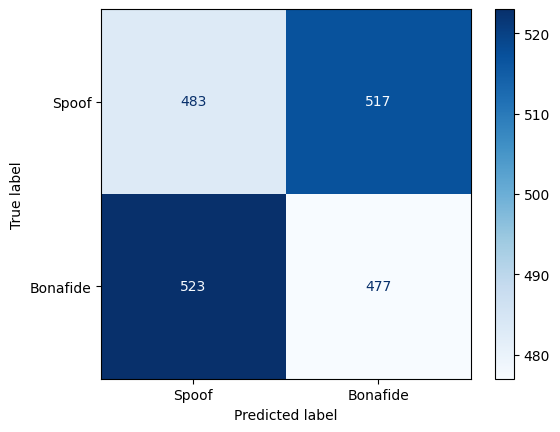


🔹 Confusion Matrix (Eval set)
2227/2227 [==============================] - 494s 222ms/step


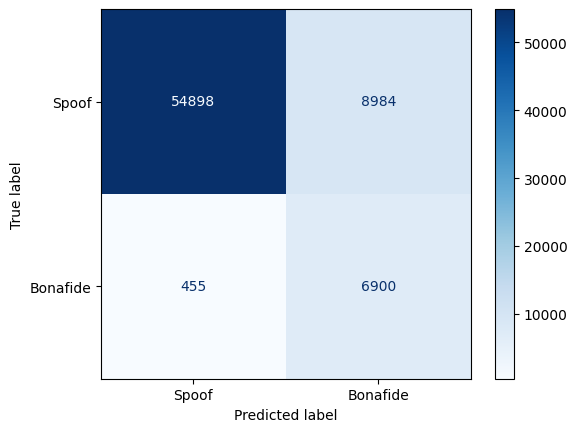

63/63 [==============================] - 13s 205ms/step


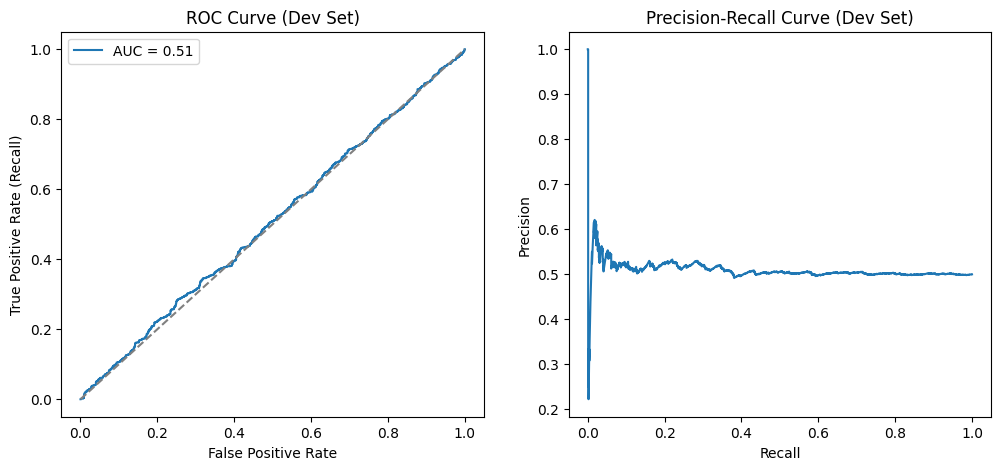


🔹 Example Mel-Spectrograms


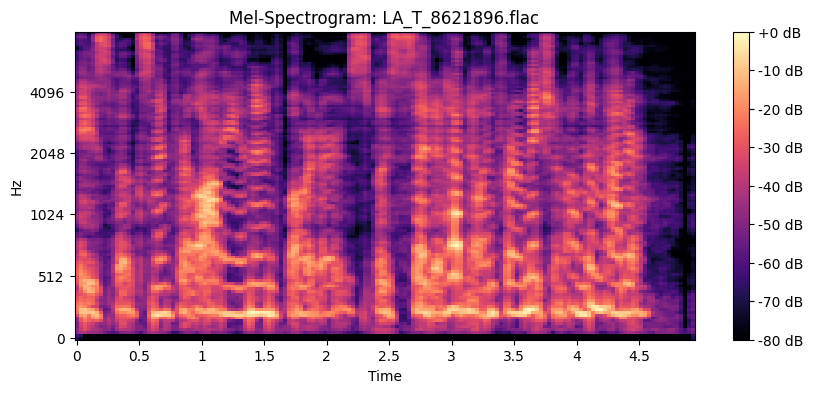

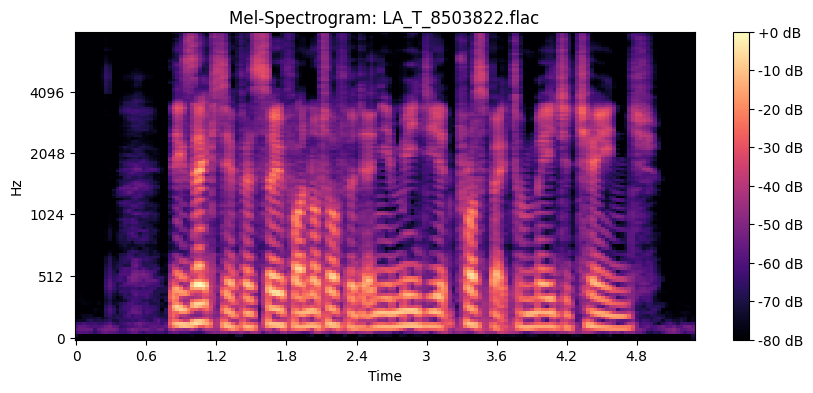

In [13]:
visualize_results(history, model, dev_gen, dev_labels, eval_gen, eval_labels, train_files)

In [19]:
# ✅ Save the trained model
model.save("deepfake_audio_detector.keras")
print("✅ Model saved successfully at deepfake_audio_detector.keras")

✅ Model saved successfully at deepfake_audio_detector.keras


In [16]:
# --- Tell PyDub exactly where ffmpeg and ffprobe are located ---
ffmpeg_folder = r"D:\ffmpeg-8.0-full_build\bin"
os.environ["PATH"] += os.pathsep + ffmpeg_folder

AudioSegment.converter = os.path.join(ffmpeg_folder, "ffmpeg.exe")
AudioSegment.ffmpeg = os.path.join(ffmpeg_folder, "ffmpeg.exe")
AudioSegment.ffprobe = os.path.join(ffmpeg_folder, "ffprobe.exe")

# --- Double-check everything exists ---
print("✅ ffmpeg path:", AudioSegment.converter)
print("✅ ffprobe path:", AudioSegment.ffprobe)
assert os.path.exists(AudioSegment.converter), "❌ ffmpeg.exe not found!"
assert os.path.exists(AudioSegment.ffprobe), "❌ ffprobe.exe not found!"

# --- Now safely convert the file ---
#input_flac = r"D:\ASVspoofDataset\unseendata\Bonafide\Deepfake_bonafide_test.flac"
input_flac = r"D:\ASVspoofDataset\unseendata\Spoof\Spoof_test.flac"
output_wav = r"D:\ASVspoofDataset\unseendata\Spoof\S_test.flac"

sound = AudioSegment.from_file(input_flac, format="flac")
sound = sound.set_frame_rate(16000).set_channels(1)
sound.export(output_wav, format="wav")

print("✅ File converted successfully to:", output_wav)

✅ ffmpeg path: D:\ffmpeg-8.0-full_build\bin\ffmpeg.exe
✅ ffprobe path: D:\ffmpeg-8.0-full_build\bin\ffprobe.exe
✅ File converted successfully to: D:\ASVspoofDataset\unseendata\Spoof\S_test.flac


In [17]:
!pip install imageio[ffmpeg]
# 🔹 Function to predict a single unseen audio file
def predict_audio(file_path, model):
    mel = extract_melspectrogram(file_path)   # reuse your existing function
    X = mel[np.newaxis, ..., np.newaxis]      # reshape for CNN
    pred = model.predict(X)[0][0]
    
    if pred > 0.5:
        return f"✅ Bonafide (Real Human) | Confidence: {pred:.2f}"
    else:
        return f"❌ Spoof (AI-generated) | Confidence: {1-pred:.2f}"

# Example usage: replace with your own recording or AI-generated file
test_file = output_wav
print(predict_audio(test_file, model))

1/1 [==============================] - 0s 16ms/step
❌ Spoof (AI-generated) | Confidence: 1.00
